In [ ]:
from datetime import datetime
import sys, os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import glob
import matplotlib.image as mpimg
import pandas as pd

# Paths
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utilities')
sys.path.insert(0, utilities_dir)


# Paths
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utilities')
sys.path.insert(0, utilities_dir)

# Custom imports
from analytical_solution_functions import sound_hard_circle_calc, mask_displacement

import importlib
import pinns_solution_functions

importlib.reload(pinns_solution_functions)
from pinns_solution_functions import (
    set_seed, generate_points, MLP, init_weights,
    train_adam_with_logs_adaptive, train_lbfgs_with_logs_adaptive,
    predict_displacement_pinns, mse_f_adaptive, mse_b_adaptive,
    split_adaptive_points, to_training_format,prepare_points_and_residuals,
    compute_rad_probability
)

# Seed
set_seed(42)

output_dir = "figs_sampling"
os.makedirs(output_dir, exist_ok=True)

#gaussian_kde
from scipy.stats import gaussian_kde

In [ ]:
def plot_sampling_and_residual(
    x_f_adaptive, y_f_adaptive, res_f,   # <-- add residuals
    x_f, y_f,
    x_inner, y_inner,
    x_left, y_left,
    x_right, y_right,
    x_bottom, y_bottom,
    x_top, y_top,
    iter
):

    fig, axes = plt.subplots(
        1, 2,
        figsize=(3.2, 2.0),
        gridspec_kw={'width_ratios': [1.0, 0.65]}  # right plot bigger
    )

    # ======================================================
    # LEFT: Residual map
    # ======================================================
    axes[0].scatter(
        x_f.detach().cpu().numpy(),
        y_f.detach().cpu().numpy(),
        s=2, alpha=0.4, rasterized=True,
        color="#AFAFAF"
    )

    axes[0].scatter(x_inner.detach().cpu(), y_inner.detach().cpu(), s=1, color='#1f77b4')
    axes[0].scatter(x_left.detach().cpu(),  y_left.detach().cpu(),  s=1, color='#006e06')
    axes[0].scatter(x_right.detach().cpu(), y_right.detach().cpu(), s=1, color="#006e06")
    axes[0].scatter(x_bottom.detach().cpu(),y_bottom.detach().cpu(),s=1, color='#006e06')
    axes[0].scatter(x_top.detach().cpu(),   y_top.detach().cpu(),   s=1, color='#006e06')

    axes[0].set_aspect('equal')
    axes[0].axis('off')

    # ======================================================
    # RIGHT: Sampling points (your original plot)
    # ======================================================

    x_all = torch.cat([
        x_f, x_inner, x_left, x_right, x_bottom, x_top
    ]).detach().cpu().numpy().flatten()

    y_all = torch.cat([
        y_f, y_inner, y_left, y_right, y_bottom, y_top
    ]).detach().cpu().numpy().flatten()

    xy = np.vstack([x_all, y_all])
    kde = gaussian_kde(xy)

    xmin, xmax = x_all.min(), x_all.max()
    ymin, ymax = y_all.min(), y_all.max()

    xx, yy = np.meshgrid(
        np.linspace(xmin, xmax, 200),
        np.linspace(ymin, ymax, 200)
    )

    grid_coords = np.vstack([xx.ravel(), yy.ravel()])
    zz = kde(grid_coords).reshape(xx.shape)

    r_i = np.pi / 4

    # Distance from center
    rr = np.sqrt(xx**2 + yy**2)

    # Mask inside the circle
    zz_masked = np.where(rr < r_i, np.nan, zz)

    # Plot
    im = axes[1].imshow(
        zz_masked,
        extent=[xmin, xmax, ymin, ymax],
        origin='lower',
        aspect='equal',
        cmap='magma',
        vmin=0, vmax=np.nanmax(zz_masked)
    )

    axes[1].axis('off')

    # Colorbar
    cbar2 = plt.colorbar(
        im,
        ax=axes[1],
        #orientation='horizontal',
        #fraction=0.05,
        #pad=0.12,
        shrink=0.95
    )
    cbar2.ax.tick_params(labelsize=8)
    vmax = np.nanmax(zz_masked) 
    cbar2.set_ticks([0, vmax])
    cbar2.set_ticklabels([f"{0:.1f}", f"{vmax*100:.2f}"])
    cbar2.ax.tick_params(labelsize=8)
    cbar2.set_label(r"Density ($\times 10^{-2}$)", fontsize=8)

    fig.text(
        0.08, 0.5, "Adaptive",   # move to left
        rotation=90,
        va='center',
        ha='left',
        fontsize=9
    ) 
    # ======================================================
    # Layout & save
    # ======================================================
    plt.tight_layout(pad=0.5, w_pad=4.0)
    plt.savefig(
        f"figures/residual_sampling_adaptive_{iter+1}.pdf",
        dpi=300,
        bbox_inches='tight',
        pad_inches=0.01
    )
    plt.close()

In [32]:
r_i = np.pi / 4
l_e = np.pi
side_length = 2 * l_e
n_grid = 501
k = 3.0

# Base sampling
n_Omega_P = 10_000
n_Gamma_I = 100
n_Gamma_E = 250

# For adaptative
n_Omega_P_adaptive = 10_000 * 10
n_Gamma_I_adaptive = 100 * 10
n_Gamma_E_adaptive = 250 * 10

# Training
adam_lr = 1e-2
adam_iters = 1_000 
lbfgs_iters = 5_000 

hidden_layers_ = 3
hidden_units_  = 25

# Grid
Y, X = np.mgrid[-l_e:l_e:n_grid*1j, -l_e:l_e:n_grid*1j]
R_exact = np.sqrt(X**2 + Y**2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Activation
class Sine(nn.Module):
    def forward(self, x):
        return torch.sin(x)

activation_function_ = Sine()

In [33]:
x_f, y_f, x_inner, y_inner, x_left, y_left, x_right, y_right, \
x_bottom, y_bottom, x_top, y_top = generate_points(
    n_Omega_P, side_length, r_i, n_Gamma_I, n_Gamma_E
)

In [34]:
u_inc_exact, u_scn_exact, u_exact = sound_hard_circle_calc(k, r_i, X, Y, n_terms=None)
u_inc_exact = mask_displacement(R_exact, r_i, l_e, u_inc_exact)
u_scn_exact = mask_displacement(R_exact, r_i, l_e, u_scn_exact)
u_exact = mask_displacement(R_exact, r_i, l_e, u_exact)

In [35]:
model = MLP(
    input_size=2,
    output_size=2,
    hidden_layers=hidden_layers_,
    hidden_units=hidden_units_,
    activation_function=activation_function_
).to(device)

model.apply(init_weights)

MLP(
  (linear_in): Linear(in_features=2, out_features=25, bias=True)
  (linear_out): Linear(in_features=25, out_features=2, bias=True)
  (layers): ModuleList(
    (0-2): 3 x Linear(in_features=25, out_features=25, bias=True)
  )
  (act): Sine()
)

In [ ]:
it = 0 

# ================= RAD LOOP =================
n_RAD_iters = 3

results = []
iter_train = 0

# -------- ADAM --------
iter_train = train_adam_with_logs_adaptive(
    model,
    x_f, y_f,
    x_inner, y_inner,
    x_left, y_left,
    x_right, y_right,
    x_bottom, y_bottom,
    x_top, y_top,
    k,
    iter_train,
    results,
    adam_lr,
    num_iter=adam_iters,
    save_csv_path=None,
    save_csv_path_no_datetime=None,
    l_e=l_e,
    r_i=r_i,
    n_grid=n_grid,
    X=X,
    Y=Y,
    R_exact=R_exact,
    u_scn_exact=u_scn_exact,
    u_exact=u_exact
)

for it in range(n_RAD_iters):


    print(f"\n===== RAD Iteration {it+1}/{n_RAD_iters} =====")


    # -------- L-BFGS --------
    iter_train, res_f, res_inner, res_left, res_right, res_bottom, res_top = train_lbfgs_with_logs_adaptive(
        model,
        x_f, y_f,
        x_inner, y_inner,
        x_left, y_left,
        x_right, y_right,
        x_bottom, y_bottom,
        x_top, y_top,
        k,
        iter_start=iter_train,
        results=results,
        lbfgs_lr=1.0,
        num_iter=lbfgs_iters,
        save_csv_path=None,
        save_csv_path_no_datetime=f'data/{it+1}_adaptive_sampling.csv',
        l_e=l_e,
        r_i=r_i,
        n_grid=n_grid,
        X=X,
        Y=Y,
        R_exact=R_exact,
        u_scn_exact=u_scn_exact,
        u_exact=u_exact
    )

    # ============================================================
    # 1. Generate candidate points
    # ============================================================
    x_f_adaptive, y_f_adaptive, \
    x_inner_adaptive, y_inner_adaptive, \
    x_left_adaptive, y_left_adaptive, \
    x_right_adaptive, y_right_adaptive, \
    x_bottom_adaptive, y_bottom_adaptive, \
    x_top_adaptive, y_top_adaptive = generate_points(
        n_Omega_P_adaptive, side_length, r_i,
        n_Gamma_I_adaptive, n_Gamma_E_adaptive
    )

    # ============================================================
    # 2. Compute residuals
    # ============================================================
    _, res_f = mse_f_adaptive(model, x_f_adaptive, y_f_adaptive, k)

    _, res_inner, res_left, res_right, res_bottom, res_top = mse_b_adaptive(
        model,
        x_inner_adaptive, y_inner_adaptive,
        x_left_adaptive, y_left_adaptive,
        x_right_adaptive, y_right_adaptive,
        x_bottom_adaptive, y_bottom_adaptive,
        x_top_adaptive, y_top_adaptive,
        k
    )

    # ============================================================
    # 3. Compute probabilities PER REGION
    # ============================================================
    prob_f     = compute_rad_probability(res_f, k=1.0, c=1.0)
    prob_inner = compute_rad_probability(res_inner, k=1.0, c=1.0)
    prob_left  = compute_rad_probability(res_left, k=1.0, c=1.0)
    prob_right = compute_rad_probability(res_right, k=1.0, c=1.0)
    prob_bottom= compute_rad_probability(res_bottom, k=1.0, c=1.0)
    prob_top   = compute_rad_probability(res_top, k=1.0, c=1.0)

    # ============================================================
    # 4. Stratified sampling (GUARANTEED POINTS)
    # ============================================================
    n_left  = n_Gamma_E // 4
    n_right = n_Gamma_E // 4
    n_bottom= n_Gamma_E // 4
    n_top   = n_Gamma_E // 4
    
    ids_f     = torch.multinomial(prob_f,     n_Omega_P, replacement=False)
    ids_inner = torch.multinomial(prob_inner, n_Gamma_I, replacement=False)
    ids_left  = torch.multinomial(prob_left,  n_left,  replacement=False)
    ids_right = torch.multinomial(prob_right, n_right, replacement=False)
    ids_bottom= torch.multinomial(prob_bottom,n_bottom,replacement=False)
    ids_top   = torch.multinomial(prob_top,   n_top,   replacement=False)

    # ============================================================
    # 5. Select points per region
    # ============================================================
    X_f_new = torch.cat([
        x_f_adaptive[ids_f].unsqueeze(1),
        y_f_adaptive[ids_f].unsqueeze(1)
    ], dim=1)

    X_inner_new = torch.cat([
        x_inner_adaptive[ids_inner].unsqueeze(1),
        y_inner_adaptive[ids_inner].unsqueeze(1)
    ], dim=1)

    X_left_new = torch.cat([
        x_left_adaptive[ids_left].unsqueeze(1),
        y_left_adaptive[ids_left].unsqueeze(1)
    ], dim=1)

    X_right_new = torch.cat([
        x_right_adaptive[ids_right].unsqueeze(1),
        y_right_adaptive[ids_right].unsqueeze(1)
    ], dim=1)

    X_bottom_new = torch.cat([
        x_bottom_adaptive[ids_bottom].unsqueeze(1),
        y_bottom_adaptive[ids_bottom].unsqueeze(1)
    ], dim=1)

    X_top_new = torch.cat([
        x_top_adaptive[ids_top].unsqueeze(1),
        y_top_adaptive[ids_top].unsqueeze(1)
    ], dim=1)

    # ============================================================
    # 6. Convert to training format
    # ============================================================
    device = x_f_adaptive.device

    x_f, y_f, \
    x_inner, y_inner, \
    x_left, y_left, \
    x_right, y_right, \
    x_bottom, y_bottom, \
    x_top, y_top = to_training_format(
        X_f_new,
        X_inner_new,
        X_left_new,
        X_right_new,
        X_bottom_new,
        X_top_new,
        device
    )

    # ============================================================
    # 7. Plot (debug / verification)
    # ============================================================
    plot_sampling_and_residual(
        x_f_adaptive, y_f_adaptive, res_f,
        x_f, y_f,
        x_inner, y_inner,
        x_left, y_left,
        x_right, y_right,
        x_bottom, y_bottom,
        x_top, y_top,
        it
    )

    


===== RAD Iteration 1/3 =====

===== RAD Iteration 2/3 =====

===== RAD Iteration 3/3 =====


In [20]:
it=0

In [119]:
# ============================================================
# 1. Generate candidate points
# ============================================================
x_f_adaptive, y_f_adaptive, \
x_inner_adaptive, y_inner_adaptive, \
x_left_adaptive, y_left_adaptive, \
x_right_adaptive, y_right_adaptive, \
x_bottom_adaptive, y_bottom_adaptive, \
x_top_adaptive, y_top_adaptive = generate_points(
    n_Omega_P_adaptive, side_length, r_i,
    n_Gamma_I_adaptive, n_Gamma_E_adaptive
)

# ============================================================
# 2. Compute residuals
# ============================================================
_, res_f = mse_f_adaptive(model, x_f_adaptive, y_f_adaptive, k)

_, res_inner, res_left, res_right, res_bottom, res_top = mse_b_adaptive(
    model,
    x_inner_adaptive, y_inner_adaptive,
    x_left_adaptive, y_left_adaptive,
    x_right_adaptive, y_right_adaptive,
    x_bottom_adaptive, y_bottom_adaptive,
    x_top_adaptive, y_top_adaptive,
    k
)

# ============================================================
# 3. Compute probabilities PER REGION
# ============================================================
prob_f     = compute_rad_probability(res_f, k=1.0, c=1.0)
prob_inner = compute_rad_probability(res_inner, k=1.0, c=1.0)
prob_left  = compute_rad_probability(res_left, k=1.0, c=1.0)
prob_right = compute_rad_probability(res_right, k=1.0, c=1.0)
prob_bottom= compute_rad_probability(res_bottom, k=1.0, c=1.0)
prob_top   = compute_rad_probability(res_top, k=1.0, c=1.0)

# ============================================================
# 4. Stratified sampling (GUARANTEED POINTS)
# ============================================================
n_left  = n_Gamma_E // 4
n_right = n_Gamma_E // 4
n_bottom= n_Gamma_E // 4
n_top   = n_Gamma_E // 4
 
ids_f     = torch.multinomial(prob_f,     n_Omega_P, replacement=False)
ids_inner = torch.multinomial(prob_inner, n_Gamma_I, replacement=False)
ids_left  = torch.multinomial(prob_left,  n_left,  replacement=False)
ids_right = torch.multinomial(prob_right, n_right, replacement=False)
ids_bottom= torch.multinomial(prob_bottom,n_bottom,replacement=False)
ids_top   = torch.multinomial(prob_top,   n_top,   replacement=False)

# ============================================================
# 5. Select points per region
# ============================================================
X_f_new = torch.cat([
    x_f_adaptive[ids_f].unsqueeze(1),
    y_f_adaptive[ids_f].unsqueeze(1)
], dim=1)

X_inner_new = torch.cat([
    x_inner_adaptive[ids_inner].unsqueeze(1),
    y_inner_adaptive[ids_inner].unsqueeze(1)
], dim=1)

X_left_new = torch.cat([
    x_left_adaptive[ids_left].unsqueeze(1),
    y_left_adaptive[ids_left].unsqueeze(1)
], dim=1)

X_right_new = torch.cat([
    x_right_adaptive[ids_right].unsqueeze(1),
    y_right_adaptive[ids_right].unsqueeze(1)
], dim=1)

X_bottom_new = torch.cat([
    x_bottom_adaptive[ids_bottom].unsqueeze(1),
    y_bottom_adaptive[ids_bottom].unsqueeze(1)
], dim=1)

X_top_new = torch.cat([
    x_top_adaptive[ids_top].unsqueeze(1),
    y_top_adaptive[ids_top].unsqueeze(1)
], dim=1)

# ============================================================
# 6. Convert to training format
# ============================================================
device = x_f_adaptive.device

x_f, y_f, \
x_inner, y_inner, \
x_left, y_left, \
x_right, y_right, \
x_bottom, y_bottom, \
x_top, y_top = to_training_format(
    X_f_new,
    X_inner_new,
    X_left_new,
    X_right_new,
    X_bottom_new,
    X_top_new,
    device
)

# ============================================================
# 7. Plot (debug / verification)
# ============================================================
plot_sampling_and_residual(
    x_f_adaptive, y_f_adaptive, res_f,
    x_f, y_f,
    x_inner, y_inner,
    x_left, y_left,
    x_right, y_right,
    x_bottom, y_bottom,
    x_top, y_top,
    it
)


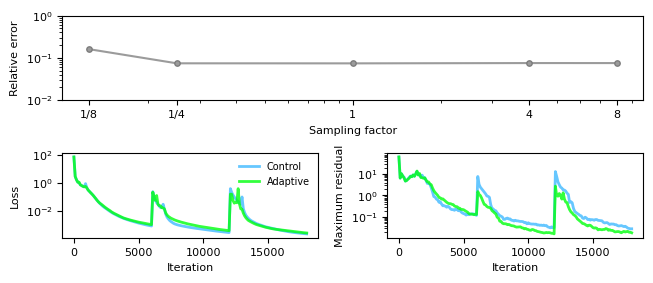

In [134]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime
import os

# ============================================================
# LOAD DATA
# ============================================================
results_control = pd.read_csv("data/control_uniform_sampling.csv")  
results_adaptive = pd.read_csv("data/3_adaptive_sampling.csv")

l2_errors = np.load("data/pinns_L2_errors_sampling_2026-04-11_15-41-14.npy")
sampling_factors = [1/8, 1/4, 1.0, 4, 8]

# Extract columns
it_c = results_control["iteration"]
max_residual_c = results_control["max_residual"]
err_c = results_control["mean_rel_error"]
loss_c = results_control["loss"]

it_a = results_adaptive["iteration"]
max_residual_a = results_adaptive["max_residual"]
err_a = results_adaptive["mean_rel_error"]
loss_a = results_adaptive["loss"]

# ============================================================
# FIGURE (2 ROWS)
# ============================================================
fig = plt.figure(figsize=(6.5, 2.8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# ============================================================
# TOP ROW: ERROR vs SAMPLING (SPAN BOTH COLUMNS)
# ============================================================
ax_top = fig.add_subplot(gs[0, :])

ax_top.plot(sampling_factors, l2_errors, color="#9b9b9b", zorder=1)
ax_top.scatter(
    sampling_factors, l2_errors,
    s=15, color="#9b9b9b", edgecolor="#7C7C7C", zorder=2
)

ax_top.set_xlabel("Sampling factor", fontsize=8)
ax_top.set_ylabel("Relative error", fontsize=8)

ax_top.set_xscale('log')
ax_top.set_xticks([1/8, 1/4, 1.0, 4, 8])
ax_top.set_xticklabels(['1/8', '1/4', '1', '4', '8'])

ax_top.set_yscale('log')
ax_top.set_ylim(1e-2, 1e0)

ax_top.tick_params(labelsize=8)

# ============================================================
# BOTTOM LEFT: LOSS
# ============================================================
ax1 = fig.add_subplot(gs[1, 0])

ax1.plot(it_c, loss_c, color="#00a2ff", linewidth=2.0, alpha=0.6)
ax1.plot(it_a, loss_a, color="#00ff0d", linewidth=2.0, alpha=0.8)

ax1.set_xlabel("Iteration", fontsize=8)
ax1.set_ylabel("Loss", fontsize=8)
ax1.set_yscale("log")
ax1.tick_params(labelsize=8)
ax1.legend(
    ["Control", "Adaptive"],
    loc="upper right",
    fontsize=7,
    frameon=False
)
# ============================================================
# BOTTOM RIGHT: MAX RESIDUAL
# ============================================================
ax2 = fig.add_subplot(gs[1, 1])

ax2.plot(it_c, max_residual_c, color="#00a2ff", linewidth=2.0, alpha=0.6)
ax2.plot(it_a, max_residual_a, color="#00ff0d", linewidth=2.0, alpha=0.8)

ax2.set_xlabel("Iteration", fontsize=8)
ax2.set_ylabel("Maximum residual", fontsize=8)
ax2.tick_params(labelsize=8)
ax2.set_yscale("log")

# ============================================================
# LEGEND (GLOBAL)
# ============================================================
# fig.legend(
#     ["Control", "Adaptive"],
#     loc="upper right",
#     fontsize=8,
#     frameon=False
# )

# ============================================================
# LAYOUT & SAVE
# ============================================================
plt.tight_layout(pad=0.6, h_pad=1.0, w_pad=1.2)

os.makedirs("figures", exist_ok=True)

plt.savefig("figures/pinns_combined_sampling.pdf", dpi=300)
plt.savefig("figures/pinns_combined_sampling.svg", dpi=300)

plt.show()

/tmp/ipykernel_1503/292581236.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


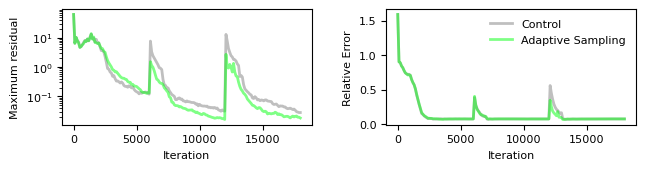

In [45]:
# Extract columns
it_c = results_control["iteration"]
loss_c = results_control["loss"]
max_residual_c = results_control["max_residual"]
err_c = results_control["mean_rel_error"]

it_a = results_adaptive["iteration"]
loss_a = results_adaptive["loss"]
max_residual_a = results_adaptive["max_residual"]
err_a = results_adaptive["mean_rel_error"]

# ================= FIGURE =================
fig, axes = plt.subplots(1, 2, figsize=(7.4, 1.5),gridspec_kw={'wspace': 0.3})

# -------- MAXIMUM RESIDUAL (LEFT PANEL) --------
axes[0].plot(it_c, max_residual_c, color="gray", linewidth=2.0, alpha=0.5)
axes[0].plot(it_a, max_residual_a, color="#00ff0d", linewidth=2.0, alpha=0.5)

axes[0].set_xlabel("Iteration", fontsize=8)
axes[0].set_ylabel("Maximum residual", fontsize=8)
axes[0].set_yscale("log")  # important
 
# -------- ERROR (RIGHT PANEL) --------
axes[1].plot(it_c, err_c, color="gray", linewidth=2.0, alpha=0.5)
axes[1].plot(it_a, err_a, color="#00ff0d", linewidth=2.0, alpha=0.5)

axes[1].set_xlabel("Iteration", fontsize=8)
axes[1].set_ylabel("Relative Error", fontsize=8)
 
# -------- Layout --------
for ax in axes:
    ax.tick_params(axis='both', labelsize=8) 

plt.legend(["Control", "Adaptive Sampling"], fontsize=8, loc="upper right", frameon=False) 
# -------- Layout --------
plt.tight_layout()
plt.savefig("figures/loss_error_adaptive_comparison.svg", dpi=300)
plt.savefig("figures/loss_error_adaptive_comparison.pdf", dpi=300)
plt.show()